PCA solved one problem:
```text
100 Features
↓
2 Features
```

But PCA has a major limitation: **PCA is Linear**

It assumes data structure can be captured using:
```text
Straight-line projections
```
Many real-world datasets are highly nonlinear.

Examples:
* Word embeddings
* Image embeddings
* Deep learning feature vectors
* Recommendation system embeddings
* Biological data

For such datasets:
```
PCA often loses structure
```

### Why t-SNE and UMAP Exist
Suppose a dataset has:

```text
768-dimensional embeddings
```

Examples:
* Transformer embeddings
* BERT embeddings
* Sentence embeddings

Humans cannot visualize:
```text
768 dimensions
```

Need:
```text
768 → 2
```

while preserving structure.

### The Goal
Convert:
```
High-dimensional space
```
into:
```
2D or 3D
```
while preserving relationships.

Example:

Original:
```
Customer A close to B
Customer A far from C
```
After reduction:

Same relationships should remain visible.

### PCA vs t-SNE vs UMAP
| Technique | Linear | Nonlinear |
| --------- | ------ | --------- |
| PCA       | Yes      | No         |
| t-SNE     | No      | Yes         |
| UMAP      | No      | Yes         |

PCA:
```
Variance Preservation
```
t-SNE:
```
Neighborhood Preservation
```
UMAP:
```
Neighborhood + Global Structure
```

### Why PCA Sometimes Fails
Imagine three clusters arranged on a curved manifold:
```text
◉────◉────◉
(curved surface)
```

PCA projects linearly.

Result:
* Clusters overlap
* Structure gets distorted

### What is t-SNE?
t-SNE stands for: **t-Distributed Stochastic Neighbor Embedding**

Developed by:
- Laurens van der Maaten, and
- Geoffrey Hinton

Core objective:
> Preserve local neighborhoods.

If two points are close in 100-dimensional space:

They should remain close in 2D.

### t-SNE Intuition
Suppose:
```text
A B C
```
are close together.

And:
```text
X Y Z
```
are another group.

t-SNE tries to ensure:
* A remains near B
* A remains near C

after projection.

### High-Dimensional Similarity
t-SNE converts distances into probabilities.

For points:
$$
x_i
$$

and
$$
x_j
$$

Similarity:
$$
P_{ij}
$$

represents probability that they are neighbors.

Nearby points:
```
High probability
```
Distant points:
```
Low probability
```

### Low-Dimensional Similarity
After projection:
$$
y_i
$$

and
$$
y_j
$$

generate:
$$
Q_{ij}
$$

Goal:

Make:
$$
P_{ij} ≈ Q_{ij}
$$

### Optimization Objective
Minimize:

**KL Divergence**
$$
KL(P∣∣Q)
$$

Meaning:

Keep neighborhood relationships similar.

### Why Student-t Distribution?
Instead of Gaussian:

t-SNE uses: **Student-t Distribution**

Reason:

Solves:
```
Crowding Problem
```
Allows distant clusters to separate better.

### What t-SNE Produces
Typical visualization:

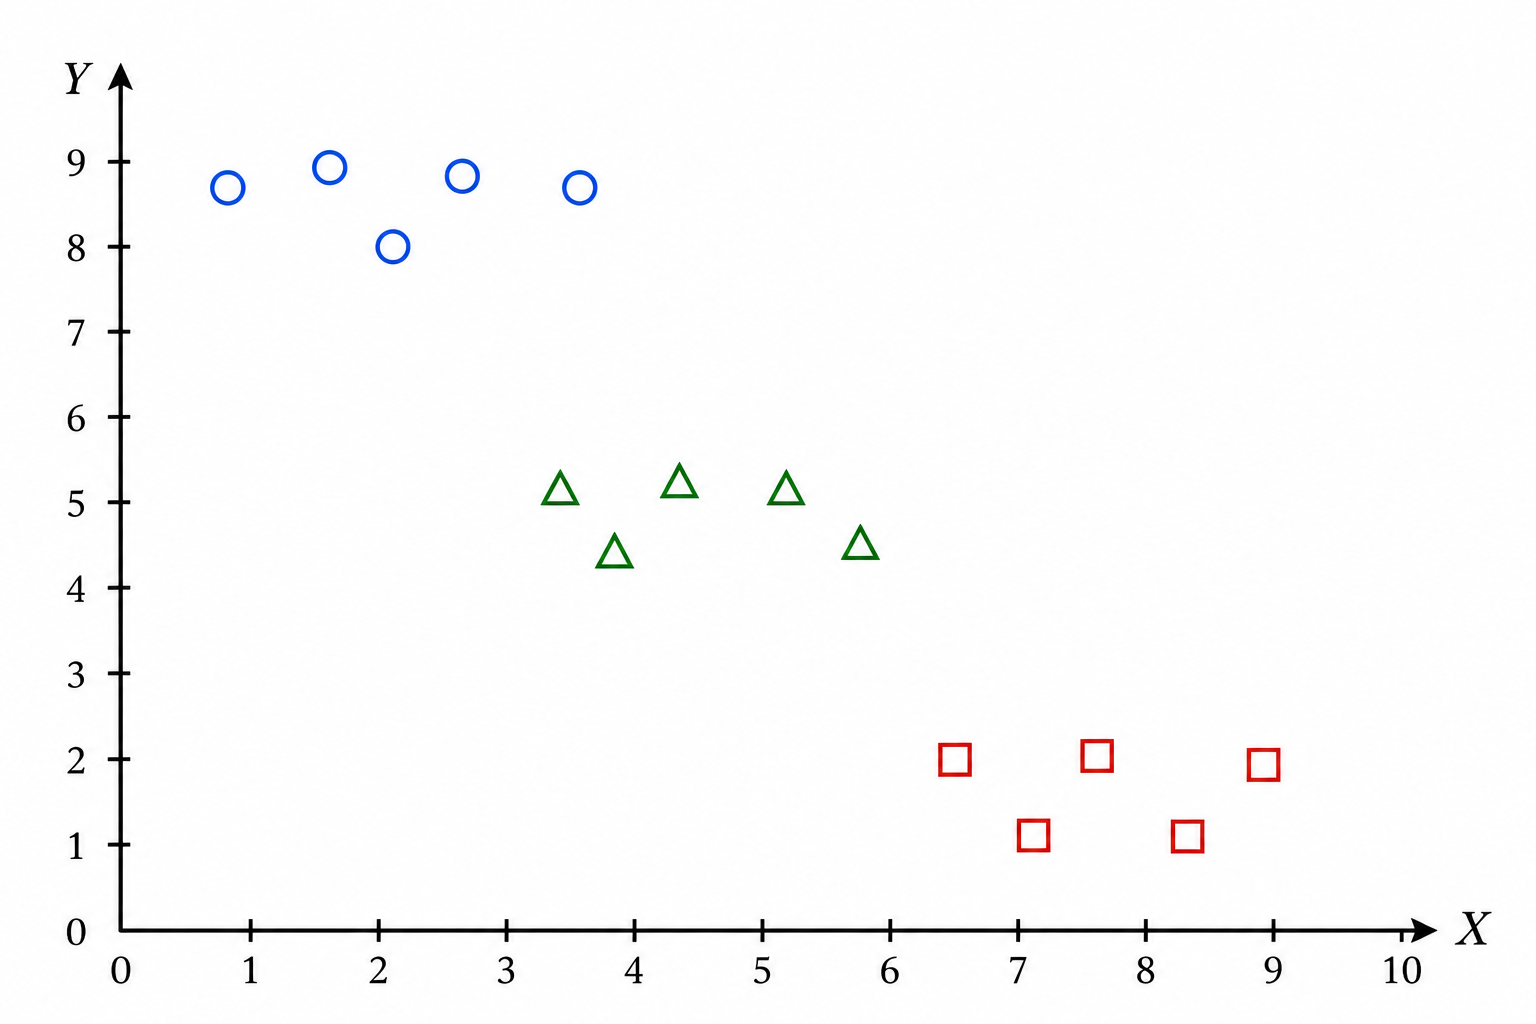

Clearly separated groups.

Excellent for visual exploration.

### Important Hyperparameter
#### Perplexity
Controls neighborhood size.

Small:
```
Very local view
```
Large:
```
More global view
```
Typical:
```python
perplexity=30
```

Range:
```text
5–50
```
commonly used.

### Python Example
```python
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)
```

### Major Limitation of t-SNE
t-SNE preserves:
```
Local Structure
```
But often loses:
```
Global Structure
```

Example:

Two clusters appear:
```
Far apart
```
in visualization.

Reality:

They may actually be fairly close.

Therefore:
```text
Distances between clusters
cannot always be trusted
```

### What is UMAP?
UMAP stands for: **Uniform Manifold Approximation and Projection**

Developed much later than t-SNE.

Now extremely popular.

Core idea:
> Preserve local neighborhoods while retaining more global structure.

### Why UMAP Became Popular
Compared with t-SNE:
- Faster
- Scales better
- Preserves more global structure
- Better for large datasets

### Mathematical Intuition of UMAP
UMAP assumes:

Data lies on a: **Manifold**

A manifold is:
```
High-dimensional surface
```
embedded in larger space.

Goal:

Recover that structure.

### UMAP Workflow
1. Construct nearest-neighbor graph
1. Learn manifold structure
1. Optimize low-dimensional embedding

Result:

Better balance between:

```text
Local Structure
+
Global Structure
```

### Important Hyperparameters
#### n_neighbors
Controls neighborhood size.

Small:
```
Local detail
```
Large:
```
Global structure
```
Common:
```python
n_neighbors=15
```

#### min_dist
Controls cluster compactness.

Small:
```
Tighter clusters
```
Large:
```
More spread clusters
```

### Python Example
```python
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)
```

### PCA vs t-SNE vs UMAP

| Feature          | PCA       | t-SNE     | UMAP      |
| ---------------- | --------- | --------- | --------- |
| Linear           | Yes         | No         | No        |
| Fast             | Very Fast | Slow      | Fast      |
| Visualization    | Good      | Excellent | Excellent |
| Global Structure | Moderate  | Weak      | Better    |
| Local Structure  | Weak      | Excellent | Excellent |
| Scalability      | Excellent | Poor      | Very Good |